# Final Pipeline: Sensor Converter + 2-Sensor Kalman Filter

This notebook builds a full end-to-end flow:
1. Generate one synthetic input CSV (`dt`, IMU 9-DoF, dual encoders, vision position).
2. Run `SensorDataConverter` on that same CSV.
3. Run a 7-state Kalman filter using two measurements per state (14 total).
4. Compare raw sensors and Kalman estimates against ground truth.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from Kalman_class import KalmanFilter
from Sensor_data_converter import SensorDataConverter

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(7)

g = 9.80665
wheel_radius_m = 0.05
track_width_m = 0.315

ROOT = Path.cwd()
SYNTH_DIR = ROOT / "csv" / "synthetic"
MEAS_DIR = ROOT / "csv" / "measurements"
CTRL_DIR = ROOT / "csv" / "controls"
SYNTH_DIR.mkdir(parents=True, exist_ok=True)
MEAS_DIR.mkdir(parents=True, exist_ok=True)

control_csv_path = CTRL_DIR / "control_inputs.csv"
input_csv_path = SYNTH_DIR / "synthetic_sensor_inputs_final_pipeline.csv"
converter_csv_path = SYNTH_DIR / "synthetic_converter_outputs_final_pipeline.csv"
measurement_csv_path = MEAS_DIR / "sensor_measurements_synthetic_final_pipeline.csv"
kalman_estimate_csv_path = SYNTH_DIR / "synthetic_kalman_estimates_final_pipeline.csv"

print("Working directory:", ROOT)
print("Control CSV:", control_csv_path)
print("Input CSV:", input_csv_path)

Working directory: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files
Control CSV: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/controls/control_inputs.csv
Input CSV: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_sensor_inputs_final_pipeline.csv


In [81]:
DT = 0.1


def build_state_transition_matrix(yaw: float, pitch: float, dt_s: float) -> np.ndarray:
    # Keep this exactly aligned with Kalman_test.ipynb
    return np.array([
        [1.0, 0.0, 0.0, np.cos(pitch) * np.cos(yaw) * dt_s, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, np.cos(pitch) * np.sin(yaw) * dt_s, 0.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, np.sin(pitch) * dt_s, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, dt_s, 1.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    ])


def build_control_matrix_original(track_width: float) -> np.ndarray:
    # Keep this aligned with Kalman_test.ipynb control model
    return np.array([
        [0.0, 0.0],
        [0.0, 0.0],
        [0.0, 0.0],
        [0.5, 0.5],
        [-0.315 / track_width, 0.315 / track_width],
        [0.0, 0.0],
        [0.0, 0.0],
    ])


def build_measurement_matrix_14x7() -> np.ndarray:
    H = np.zeros((14, 7), dtype=float)
    mapping = {
        0: [0, 7],
        1: [1, 8],
        2: [2, 9],
        3: [3, 10],
        4: [4, 11],
        5: [5, 12],
        6: [6, 13],
    }
    for state_idx, rows in mapping.items():
        for r in rows:
            H[r, state_idx] = 1.0
    return H

## 1) Generate One Consistent Synthetic Input Dataset

The generated motion and all sensor channels are derived from the same underlying trajectory.

In [82]:
control_df = pd.read_csv(control_csv_path).sort_values("t_s").reset_index(drop=True)
if control_df.shape[0] < 3:
    raise ValueError("control_inputs.csv must have at least 3 rows")

control_t_s = control_df["t_s"].to_numpy(dtype=float)
control_u_left = control_df["u_left"].to_numpy(dtype=float)
control_u_right = control_df["u_right"].to_numpy(dtype=float)

num_samples = len(control_df)
control_dt = np.diff(control_t_s)
nominal_dt = float(np.median(control_dt)) if control_dt.size else DT

# Keep slight timestamp variation so Kalman variable-dt handling is exercised.
USE_VARIABLE_INPUT_DT = True
INPUT_DT_JITTER_FRAC = 0.10
if USE_VARIABLE_INPUT_DT:
    dt_s = nominal_dt * (1.0 + rng.normal(0.0, INPUT_DT_JITTER_FRAC, num_samples))
    dt_s = np.clip(dt_s, 0.5 * nominal_dt, 1.5 * nominal_dt)
    dt_s[0] = nominal_dt
    t_s = np.cumsum(dt_s) - dt_s[0]
    u_left = np.interp(t_s, control_t_s, control_u_left)
    u_right = np.interp(t_s, control_t_s, control_u_right)
else:
    t_s = control_t_s.copy()
    u_left = control_u_left.copy()
    u_right = control_u_right.copy()
    dt_s = np.diff(t_s, prepend=t_s[0])
    if dt_s[0] <= 0.0:
        dt_s[0] = nominal_dt
    dt_s = np.clip(dt_s, 1e-4, None)

# Dynamics driven by control inputs.
velocity_gain = 1.0
tau_v = 0.45
tau_w = 0.30

velocity_true = np.zeros(num_samples, dtype=float)
yaw_rate_true = np.zeros(num_samples, dtype=float)
yaw_true = np.zeros(num_samples, dtype=float)

pitch_true = np.zeros(num_samples, dtype=float)
roll_true = np.zeros(num_samples, dtype=float)

for i in range(1, num_samples):
    dt = dt_s[i]
    v_cmd = velocity_gain * 0.5 * (u_left[i] + u_right[i])
    w_cmd = velocity_gain * (u_right[i] - u_left[i]) / track_width_m

    velocity_true[i] = velocity_true[i - 1] + (dt / tau_v) * (v_cmd - velocity_true[i - 1])
    yaw_rate_true[i] = yaw_rate_true[i - 1] + (dt / tau_w) * (w_cmd - yaw_rate_true[i - 1])
    yaw_true[i] = yaw_true[i - 1] + yaw_rate_true[i] * dt

    pitch_cmd = 0.05 * np.tanh(0.9 * (v_cmd - velocity_true[i]))
    roll_cmd = 0.04 * np.tanh(1.1 * yaw_rate_true[i])
    pitch_true[i] = pitch_true[i - 1] + (dt / 0.5) * (pitch_cmd - pitch_true[i - 1])
    roll_true[i] = roll_true[i - 1] + (dt / 0.35) * (roll_cmd - roll_true[i - 1])

pitch_rate_true = np.gradient(pitch_true, t_s)
roll_rate_true = np.gradient(roll_true, t_s)
acc_forward_true = np.gradient(velocity_true, t_s)

pos_x_true = np.zeros_like(t_s)
pos_y_true = np.zeros_like(t_s)
pos_z_true = np.zeros_like(t_s)
for i in range(1, num_samples):
    ds = velocity_true[i] * dt_s[i]
    pos_x_true[i] = pos_x_true[i - 1] + ds * np.cos(pitch_true[i]) * np.cos(yaw_true[i])
    pos_y_true[i] = pos_y_true[i - 1] + ds * np.cos(pitch_true[i]) * np.sin(yaw_true[i])
    pos_z_true[i] = pos_z_true[i - 1] + ds * np.sin(pitch_true[i])

# IMU signals consistent with the same trajectory.
ax_mps2 = acc_forward_true - g * np.sin(pitch_true) + rng.normal(0.0, 0.06, num_samples)
ay_mps2 = g * np.sin(roll_true) * np.cos(pitch_true) + rng.normal(0.0, 0.06, num_samples)
az_mps2 = g * np.cos(roll_true) * np.cos(pitch_true) + rng.normal(0.0, 0.06, num_samples)

gx_radps = roll_rate_true + rng.normal(0.0, 0.003, num_samples)
gy_radps = pitch_rate_true + rng.normal(0.0, 0.003, num_samples)
gz_radps = yaw_rate_true * np.cos(pitch_true) + rng.normal(0.0, 0.003, num_samples)

mx = np.cos(yaw_true) * np.cos(pitch_true) + rng.normal(0.0, 0.008, num_samples)
my = -np.sin(yaw_true) * np.cos(roll_true) + rng.normal(0.0, 0.008, num_samples)
mz = np.sin(pitch_true) + rng.normal(0.0, 0.008, num_samples)

v_left = velocity_true - 0.5 * track_width_m * yaw_rate_true
v_right = velocity_true + 0.5 * track_width_m * yaw_rate_true
encoder_left_radps = (v_left / wheel_radius_m) + rng.normal(0.0, 0.04, num_samples)
encoder_right_radps = (v_right / wheel_radius_m) + rng.normal(0.0, 0.04, num_samples)

vision_px_m = pos_x_true + rng.normal(0.0, 0.03, num_samples)
vision_py_m = pos_y_true + rng.normal(0.0, 0.03, num_samples)
vision_pz_m = pos_z_true + rng.normal(0.0, 0.02, num_samples)

input_df = pd.DataFrame(
    {
        "t_s": t_s,
        "dt_s": dt_s,
        "u_left": u_left,
        "u_right": u_right,
        "ax_mps2": ax_mps2,
        "ay_mps2": ay_mps2,
        "az_mps2": az_mps2,
        "gx_radps": gx_radps,
        "gy_radps": gy_radps,
        "gz_radps": gz_radps,
        "mx": mx,
        "my": my,
        "mz": mz,
        "encoder_left_radps": encoder_left_radps,
        "encoder_right_radps": encoder_right_radps,
        "vision_px_m": vision_px_m,
        "vision_py_m": vision_py_m,
        "vision_pz_m": vision_pz_m,
    }
)

input_df.to_csv(input_csv_path, index=False)
print("Generated input shape:", input_df.shape)
print("Saved:", input_csv_path)
print(
    f"dt stats [s] -> mean={dt_s.mean():.4f}, std={dt_s.std():.4f}, "
    f"min={dt_s.min():.4f}, max={dt_s.max():.4f}"
)
input_df.head(3)

Generated input shape: (100, 18)
Saved: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_sensor_inputs_final_pipeline.csv
dt stats [s] -> mean=0.0983, std=0.0088, min=0.0748, max=0.1200


,t_s,dt_s,u_left,u_right,ax_mps2,ay_mps2,az_mps2,gx_radps,gy_radps,gz_radps,mx,my,mz,encoder_left_radps,encoder_right_radps,vision_px_m,vision_py_m,vision_pz_m
0,0.000000,0.100000,1.0,1.0,2.203954,-0.074796,9.897360,0.000526,0.059200,-0.004918,0.998130,0.005575,0.009077,0.014352,0.012072,-0.040996,0.002555,-0.024049
1,0.102987,0.102987,1.0,1.0,1.846008,0.051703,9.839804,0.001176,0.043799,0.001742,0.997050,-0.000891,0.024688,4.592884,4.677580,0.029852,0.005258,-0.003400
2,0.200246,0.097259,1.0,1.0,1.436075,0.029636,9.802671,-0.001131,0.026045,-0.000165,1.009647,0.002855,0.025984,7.893723,7.941906,0.046119,-0.015922,-0.043532


## 2) Run Sensor Converter on the Same Input CSV

We feed each row into `SensorDataConverter` and keep the 14-column measurement layout.

In [83]:
loaded_input_df = pd.read_csv(input_csv_path)
converter = SensorDataConverter(wheel_radius_m=wheel_radius_m)

converter_rows = []
for row in loaded_input_df.itertuples(index=False):
    out = converter.update(
        dt_s=float(row.dt_s),
        vision_pos_xyz_m=(row.vision_px_m, row.vision_py_m, row.vision_pz_m),
        encoder_left=float(row.encoder_left_radps),
        encoder_right=float(row.encoder_right_radps),
        accel_xyz_mps2=(row.ax_mps2, row.ay_mps2, row.az_mps2),
        gyro_xyz_radps=(row.gx_radps, row.gy_radps, row.gz_radps),
        mag_xyz=(row.mx, row.my, row.mz),
        encoder_input_mode="angular_radps",
    )
    converter_rows.append(out)

converter_df = pd.DataFrame(converter_rows)
converter_df.to_csv(converter_csv_path, index=False)

measurement_df = pd.concat(
    [loaded_input_df[["t_s", "dt_s", "u_left", "u_right"]].reset_index(drop=True), converter_df.reset_index(drop=True)],
    axis=1,
)
measurement_df.to_csv(measurement_csv_path, index=False)

print("Converter output shape:", converter_df.shape)
print("Saved:", converter_csv_path)
print("Saved Kalman measurement file:", measurement_csv_path)
measurement_df.head(3)

Converter output shape: (100, 14)
Saved: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_converter_outputs_final_pipeline.csv
Saved Kalman measurement file: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/measurements/sensor_measurements_synthetic_final_pipeline.csv


,t_s,dt_s,u_left,u_right,pos_x_s1,pos_y_s1,pos_z_s1,velocity_s1,angular_velocity_s1,yaw_s1,pitch_s1,pos_x_s2,pos_y_s2,pos_z_s2,velocity_s2,angular_velocity_s2,yaw_s2,pitch_s2
0,0.000000,0.100000,1.0,1.0,-0.040996,0.002555,-0.024049,0.000661,0.000000,-0.005734,-0.219100,0.000066,-3.328593e-08,3.910717e-07,0.224147,-0.005039,-0.000504,0.005920
1,0.102987,0.102987,1.0,1.0,0.029852,0.005258,-0.003400,0.231762,0.064552,0.000914,-0.185448,0.023933,-7.702985e-06,2.493535e-04,0.438479,0.001772,-0.000321,0.010431
2,0.200246,0.097259,1.0,1.0,0.046119,-0.015922,-0.043532,0.395891,-0.038889,-0.002868,-0.145463,0.062434,-2.070111e-05,7.484987e-04,0.606333,-0.000167,-0.000338,0.012964


## 3) Run 7-State Kalman Filter With 14 Measurements

State order: `[pos_x, pos_y, pos_z, velocity, angular_velocity, yaw, pitch]`.

In [84]:
H = build_measurement_matrix_14x7()

Q = np.diag([
    2e-4,
    2e-4,
    2e-4,
    4e-4,
    2e-4,
    3e-4,
    3e-4,
])

# R follows converter output order: [s1(7 states), s2(7 states)]
r_diag = np.array([
    0.03**2,  # pos_x_s1
    0.03**2,  # pos_y_s1
    0.02**2,  # pos_z_s1
    0.01**2,  # velocity_s1
    1.20**2,  # angular_velocity_s1
    0.015**2, # yaw_s1
    0.012**2, # pitch_s1
    0.05**2,  # pos_x_s2
    0.05**2,  # pos_y_s2
    0.06**2,  # pos_z_s2
    0.15**2,  # velocity_s2
    0.02**2,  # angular_velocity_s2
    0.012**2, # yaw_s2
    0.02**2,  # pitch_s2
])
R = np.diag(r_diag)


def build_step_dts(time_values: np.ndarray, default_dt: float) -> np.ndarray:
    dts = np.empty_like(time_values)
    dts[0] = default_dt
    for i in range(1, len(time_values)):
        dts[i] = max(1e-4, float(time_values[i] - time_values[i - 1]))
    return dts


step_dts = build_step_dts(measurement_df["t_s"].to_numpy(dtype=float), default_dt=DT)
# Dual-sensor Kalman behavior: can toggle variable dynamics dt on/off.
USE_VARIABLE_DT_IN_DYNAMICS = True
model_step_dts = step_dts.copy() if USE_VARIABLE_DT_IN_DYNAMICS else np.full_like(step_dts, DT)

A0 = build_state_transition_matrix(0.0, 0.0, float(model_step_dts[0]))
B0 = build_control_matrix_original(track_width_m)
kf = KalmanFilter(A0, B0, H, Q, R)

z0 = converter_df.iloc[0]
kf.x = np.array(
    [
        [float(z0["pos_x_s1"])],
        [float(z0["pos_y_s1"])],
        [float(z0["pos_z_s1"])],
        [float(z0["velocity_s1"])],
        [float(z0["angular_velocity_s2"])],
        [0.5 * float(z0["yaw_s1"] + z0["yaw_s2"])],
        [0.5 * float(z0["pitch_s1"] + z0["pitch_s2"])],
    ],
    dtype=float,
)
kf.P = np.diag([0.2, 0.2, 0.2, 0.1, 0.1, 0.15, 0.15])

state_history = []
for i, row in enumerate(measurement_df.itertuples(index=False)):
    dt_model = float(model_step_dts[i])
    yaw_hat = float(kf.x[5, 0])
    pitch_hat = float(kf.x[6, 0])

    # Original transition model with selectable fixed/variable dynamics dt.
    kf.A = build_state_transition_matrix(yaw_hat, pitch_hat, dt_model)
    kf.B = B0

    z = np.array(
        [
            [row.pos_x_s1], [row.pos_y_s1], [row.pos_z_s1],
            [row.velocity_s1], [row.angular_velocity_s1], [row.yaw_s1], [row.pitch_s1],
            [row.pos_x_s2], [row.pos_y_s2], [row.pos_z_s2],
            [row.velocity_s2], [row.angular_velocity_s2], [row.yaw_s2], [row.pitch_s2],
        ],
        dtype=float,
    )

    u = np.array([[float(row.u_left)], [float(row.u_right)]], dtype=float)
    kf.predict(u)
    kf.update(z)
    state_history.append(kf.x.flatten())

kalman_df = pd.DataFrame(
    state_history,
    columns=[
        "pos_x_kf",
        "pos_y_kf",
        "pos_z_kf",
        "velocity_kf",
        "angular_velocity_kf",
        "yaw_kf",
        "pitch_kf",
    ],
)

kalman_df = pd.concat([measurement_df[["t_s", "dt_s"]].reset_index(drop=True), kalman_df], axis=1)
kalman_df.to_csv(kalman_estimate_csv_path, index=False)
print("Kalman estimates shape:", kalman_df.shape)
print("Saved:", kalman_estimate_csv_path)
print("USE_VARIABLE_DT_IN_DYNAMICS:", USE_VARIABLE_DT_IN_DYNAMICS)
kalman_df.head(3)

Kalman estimates shape: (100, 9)
Saved: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_kalman_estimates_final_pipeline.csv
USE_VARIABLE_DT_IN_DYNAMICS: True


,t_s,dt_s,pos_x_kf,pos_y_kf,pos_z_kf,velocity_kf,angular_velocity_kf,yaw_kf,pitch_kf
0,0.000000,0.100000,-0.030162,0.001881,-0.021649,0.200612,-0.001679,-0.002546,-0.159499
1,0.102987,0.102987,0.011742,0.002979,-0.011610,0.385597,0.000597,-0.000369,-0.138957
2,0.200246,0.097259,0.049608,-0.003852,-0.028800,0.517030,-0.000059,-0.001132,-0.111185


## 4) Evaluate Against Ground Truth

Compute RMSE for both converter sensors (`s1`,`s2`) and the Kalman estimate (`kf`).

In [85]:
truth_df = pd.DataFrame(
    {
        "pos_x_gt": pos_x_true,
        "pos_y_gt": pos_y_true,
        "pos_z_gt": pos_z_true,
        "velocity_gt": velocity_true,
        "angular_velocity_gt": yaw_rate_true,
        "yaw_gt": yaw_true,
        "pitch_gt": pitch_true,
    }
)

compare_specs = [
    ("pos_x", "pos_x_s1", "pos_x_s2", "pos_x_kf", "pos_x_gt", "m"),
    ("pos_y", "pos_y_s1", "pos_y_s2", "pos_y_kf", "pos_y_gt", "m"),
    ("pos_z", "pos_z_s1", "pos_z_s2", "pos_z_kf", "pos_z_gt", "m"),
    ("velocity", "velocity_s1", "velocity_s2", "velocity_kf", "velocity_gt", "m/s"),
    ("angular_velocity", "angular_velocity_s1", "angular_velocity_s2", "angular_velocity_kf", "angular_velocity_gt", "rad/s"),
    ("yaw", "yaw_s1", "yaw_s2", "yaw_kf", "yaw_gt", "rad"),
    ("pitch", "pitch_s1", "pitch_s2", "pitch_kf", "pitch_gt", "rad"),
]

rmse_rows = []
for state_name, s1_col, s2_col, kf_col, gt_col, _unit in compare_specs:
    gt = truth_df[gt_col].to_numpy()
    s1 = converter_df[s1_col].to_numpy()
    s2 = converter_df[s2_col].to_numpy()
    kf_vals = kalman_df[kf_col].to_numpy()

    rmse_rows.append(
        {
            "state": state_name,
            "rmse_s1": float(np.sqrt(np.mean((s1 - gt) ** 2))),
            "rmse_s2": float(np.sqrt(np.mean((s2 - gt) ** 2))),
            "rmse_kf": float(np.sqrt(np.mean((kf_vals - gt) ** 2))),
        }
    )

rmse_df = pd.DataFrame(rmse_rows)
rmse_df

,state,rmse_s1,rmse_s2,rmse_kf
0,pos_x,0.029538,0.004153,0.012270
1,pos_y,0.035198,0.003670,0.014110
2,pos_z,0.021407,0.004026,0.012297
3,velocity,0.001447,0.182652,0.034996
4,angular_velocity,0.104181,0.002975,0.236261
5,yaw,0.007686,0.001720,0.005851
6,pitch,0.043433,0.002173,0.032474


## 5) Plot Results + 3D GIF

Plot each state against truth (`s1`, `s2`, `kf`), show XY trajectory comparison, and export a 3D trajectory GIF.

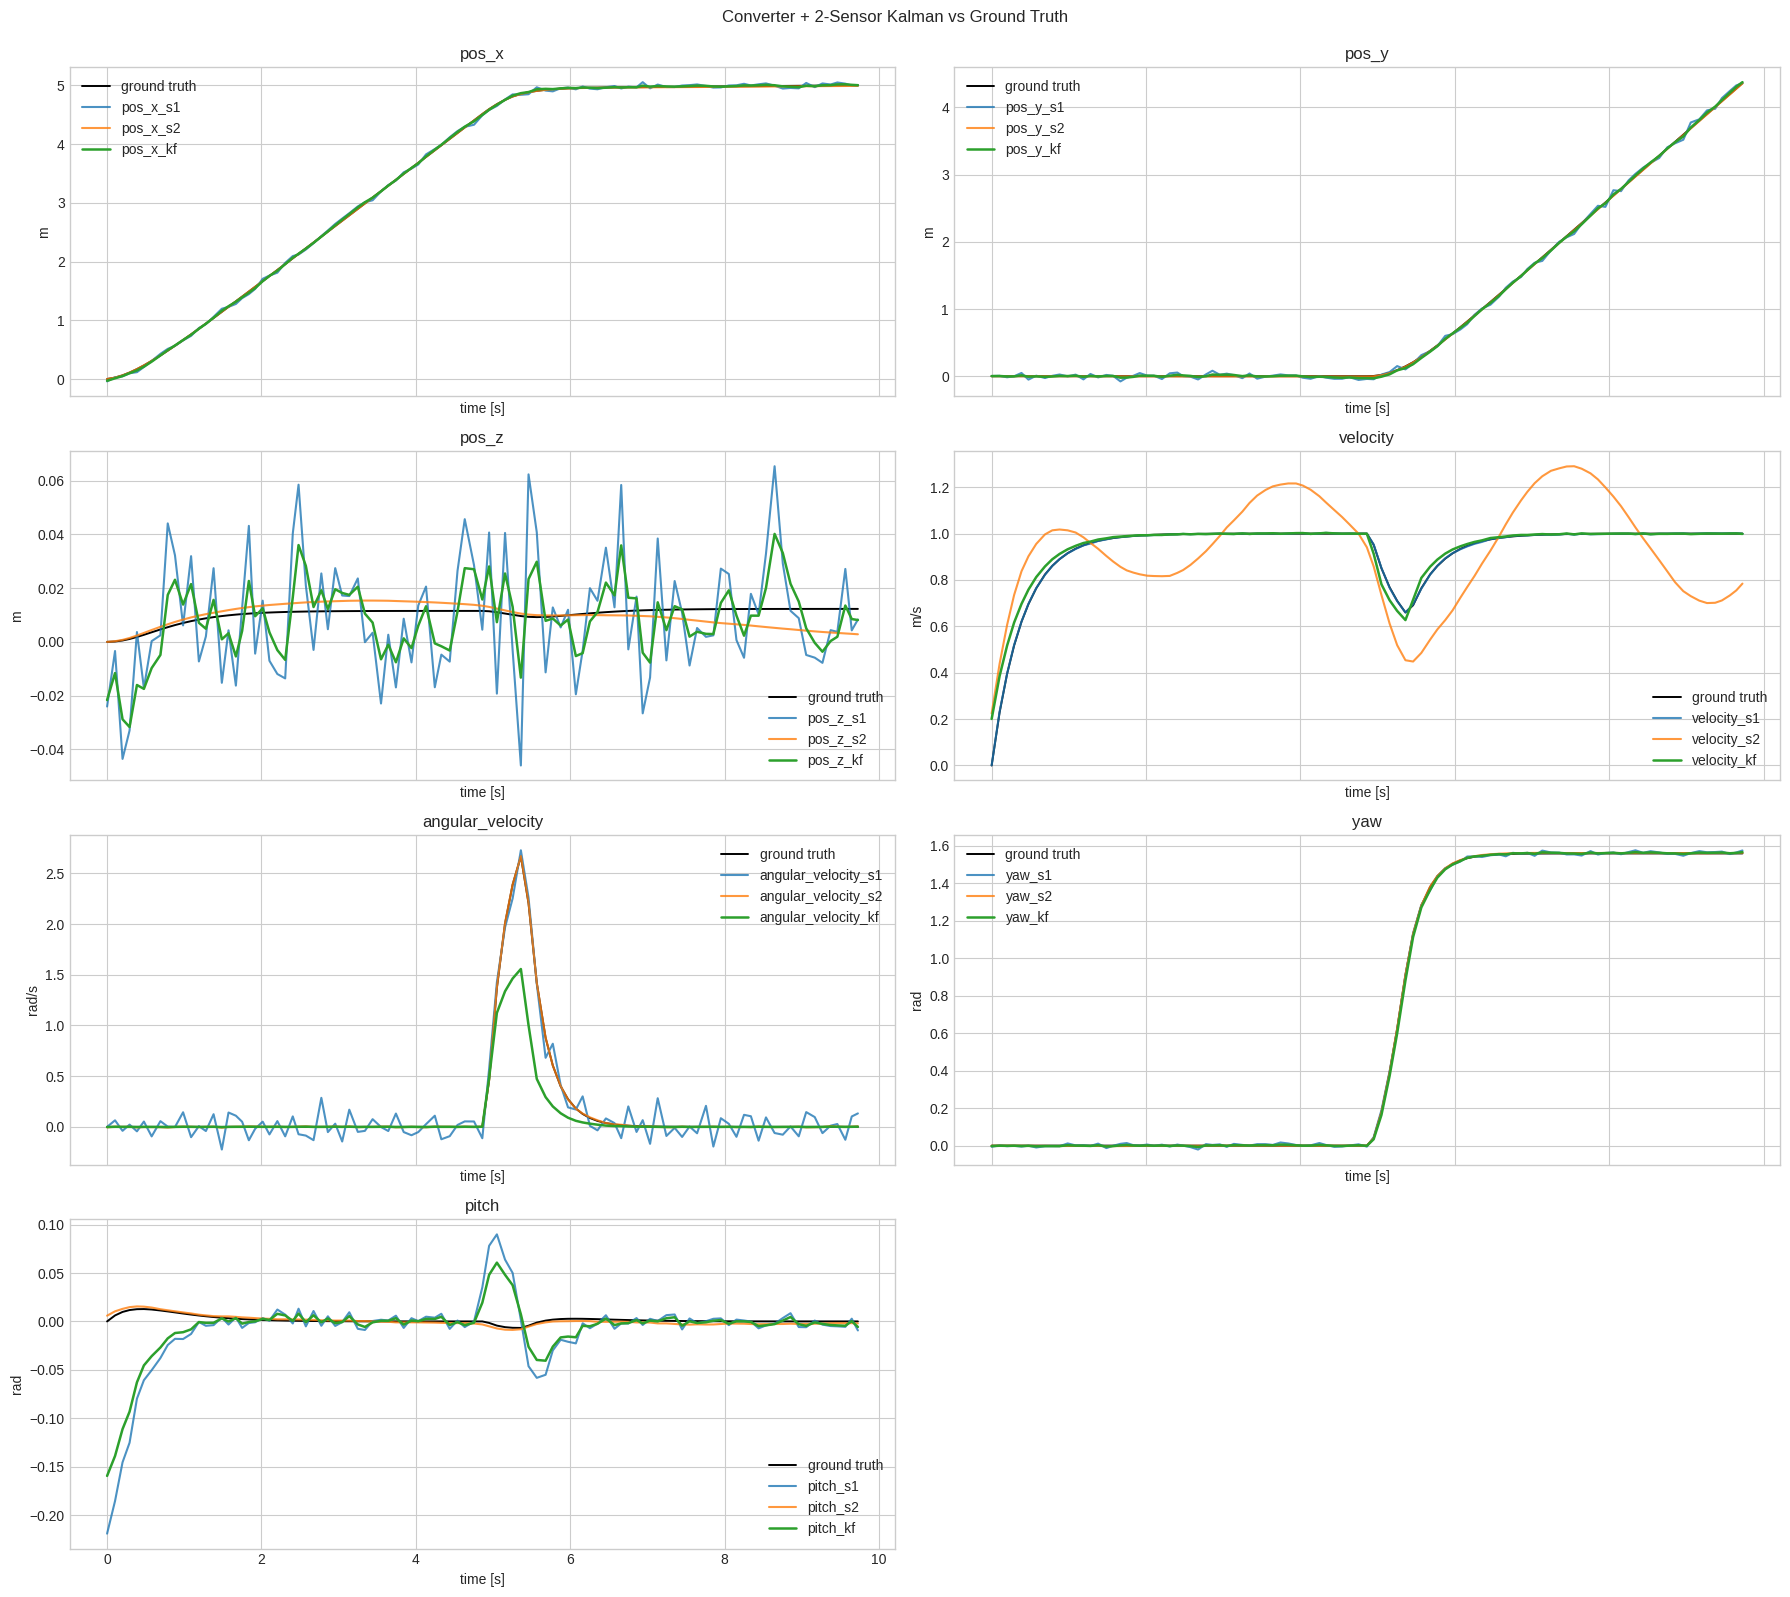

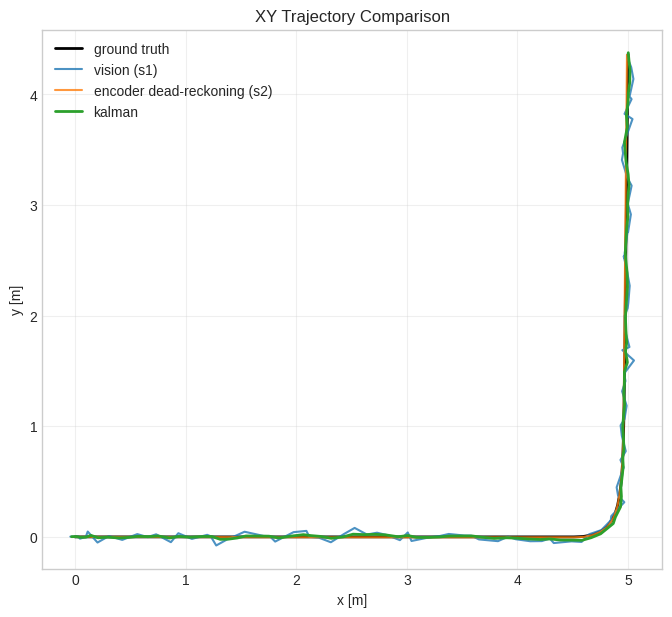

Saved 3D GIF: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/estimated_position_trajectory_3d.gif


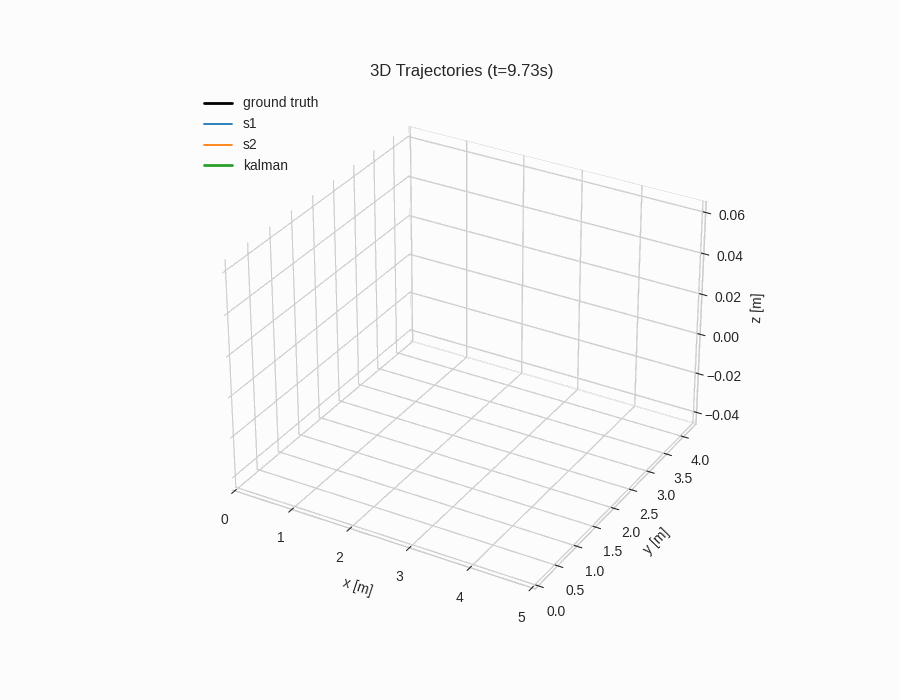

In [86]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

fig, axes = plt.subplots(4, 2, figsize=(18, 16), sharex=True)
axes = axes.ravel()

for i, (state_name, s1_col, s2_col, kf_col, gt_col, unit) in enumerate(compare_specs):
    ax = axes[i]
    ax.plot(t_s, truth_df[gt_col], color="black", linewidth=1.4, label="ground truth")
    ax.plot(t_s, converter_df[s1_col], alpha=0.8, label=s1_col)
    ax.plot(t_s, converter_df[s2_col], alpha=0.8, label=s2_col)
    ax.plot(t_s, kalman_df[kf_col], linewidth=1.8, label=kf_col)
    ax.set_title(state_name)
    ax.set_ylabel(unit)
    ax.legend(loc="best")

axes[7].axis("off")
for ax in axes[:-1]:
    ax.set_xlabel("time [s]")

fig.suptitle("Converter + 2-Sensor Kalman vs Ground Truth", y=0.995)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))
plt.plot(truth_df["pos_x_gt"], truth_df["pos_y_gt"], color="black", linewidth=2, label="ground truth")
plt.plot(converter_df["pos_x_s1"], converter_df["pos_y_s1"], alpha=0.8, label="vision (s1)")
plt.plot(converter_df["pos_x_s2"], converter_df["pos_y_s2"], alpha=0.8, label="encoder dead-reckoning (s2)")
plt.plot(kalman_df["pos_x_kf"], kalman_df["pos_y_kf"], linewidth=2, label="kalman")
plt.title("XY Trajectory Comparison")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.show()

# Save a 3D trajectory GIF (truth vs sensors vs Kalman)
fig3d = plt.figure(figsize=(9, 7))
ax3d = fig3d.add_subplot(111, projection="3d")

x_gt = truth_df["pos_x_gt"].to_numpy()
y_gt = truth_df["pos_y_gt"].to_numpy()
z_gt = truth_df["pos_z_gt"].to_numpy()

x_s1 = converter_df["pos_x_s1"].to_numpy()
y_s1 = converter_df["pos_y_s1"].to_numpy()
z_s1 = converter_df["pos_z_s1"].to_numpy()

x_s2 = converter_df["pos_x_s2"].to_numpy()
y_s2 = converter_df["pos_y_s2"].to_numpy()
z_s2 = converter_df["pos_z_s2"].to_numpy()

x_kf = kalman_df["pos_x_kf"].to_numpy()
y_kf = kalman_df["pos_y_kf"].to_numpy()
z_kf = kalman_df["pos_z_kf"].to_numpy()

line_gt, = ax3d.plot([], [], [], color="black", lw=2.0, label="ground truth")
line_s1, = ax3d.plot([], [], [], color="tab:blue", lw=1.3, label="s1")
line_s2, = ax3d.plot([], [], [], color="tab:orange", lw=1.3, label="s2")
line_kf, = ax3d.plot([], [], [], color="tab:green", lw=2.0, label="kalman")

x_all = np.concatenate([x_gt, x_s1, x_s2, x_kf])
y_all = np.concatenate([y_gt, y_s1, y_s2, y_kf])
z_all = np.concatenate([z_gt, z_s1, z_s2, z_kf])

ax3d.set_xlim(x_all.min(), x_all.max())
ax3d.set_ylim(y_all.min(), y_all.max())
ax3d.set_zlim(z_all.min(), z_all.max())
ax3d.set_xlabel("x [m]")
ax3d.set_ylabel("y [m]")
ax3d.set_zlabel("z [m]")
ax3d.legend(loc="upper left")


def _anim(frame: int):
    line_gt.set_data(x_gt[:frame], y_gt[:frame])
    line_gt.set_3d_properties(z_gt[:frame])

    line_s1.set_data(x_s1[:frame], y_s1[:frame])
    line_s1.set_3d_properties(z_s1[:frame])

    line_s2.set_data(x_s2[:frame], y_s2[:frame])
    line_s2.set_3d_properties(z_s2[:frame])

    line_kf.set_data(x_kf[:frame], y_kf[:frame])
    line_kf.set_3d_properties(z_kf[:frame])

    ax3d.set_title(f"3D Trajectories (t={t_s[frame-1]:.2f}s)")
    return line_gt, line_s1, line_s2, line_kf

ani = FuncAnimation(fig3d, _anim, frames=len(t_s), interval=100, blit=False)
gif_out = ROOT / "estimated_position_trajectory_3d.gif"
ani.save(gif_out, writer=PillowWriter(fps=10))
plt.close(fig3d)
print("Saved 3D GIF:", gif_out)

# Show GIF inline in notebook output
display(Image(filename=str(gif_out)))